In [1]:
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM

# ---------------------------------------
# Cosmology (same as your script)
# ---------------------------------------
COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
REDSHIFT = 6.9

# ---------------------------------------
# Angular scale
# ---------------------------------------
ARCSEC_PER_KPC = COSMO.arcsec_per_kpc_proper(REDSHIFT)

# ---------------------------------------
# Distance to convert
# ---------------------------------------
distance = 5 * u.Mpc

# Convert Mpc → kpc
distance_kpc = distance.to(u.kpc)

# Angular size
theta_arcsec = distance_kpc * ARCSEC_PER_KPC

print("Angular size:")
print(theta_arcsec)

print("In arcminutes:")
print(theta_arcsec.to(u.arcmin))

print("In degrees:")
print(theta_arcsec.to(u.deg))

Angular size:
948.172938708838 arcsec
In arcminutes:
15.802882311813967 arcmin
In degrees:
0.26338137186356614 deg



FILE: /Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_i.weight.fits.fz

Basic statistics:
Min: -0.0257907
Max: 0.5087822
Mean: 0.19812566
Std: 0.21639675

Negative pixels: 149650339

Unique values (first 10): [-0.0257907  -0.02379817 -0.0236539  -0.0226021  -0.02210898 -0.02167656
 -0.02160753 -0.02150028 -0.02112411 -0.0210578 ]
Total unique values: 126050918

If this is RMS, mean variance would be ~: 0.0861152

Header hints:


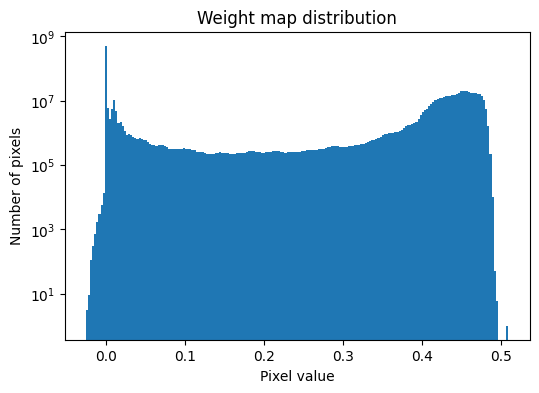


Suggested SExtractor WEIGHT_TYPE:
MAP_RMS (negative values indicate RMS noise map)

Done.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# --------------------------------------------------
# FILE TO TEST
# --------------------------------------------------
file = "/Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_i.weight.fits.fz"

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
data = fits.getdata(file)
header = fits.getheader(file)

# remove NaNs for statistics
clean = data[np.isfinite(data)]

print("\n==============================")
print("FILE:", file)
print("==============================")

# --------------------------------------------------
# BASIC STATISTICS
# --------------------------------------------------
print("\nBasic statistics:")
print("Min:", np.min(clean))
print("Max:", np.max(clean))
print("Mean:", np.mean(clean))
print("Std:", np.std(clean))

# --------------------------------------------------
# NEGATIVE VALUE CHECK
# --------------------------------------------------
neg = np.sum(clean < 0)

print("\nNegative pixels:", neg)

# --------------------------------------------------
# UNIQUE VALUE CHECK (mask detection)
# --------------------------------------------------
unique_vals = np.unique(clean)

print("\nUnique values (first 10):", unique_vals[:10])
print("Total unique values:", len(unique_vals))

# --------------------------------------------------
# RMS -> VAR TEST
# --------------------------------------------------
variance_test = clean**2
print("\nIf this is RMS, mean variance would be ~:", np.mean(variance_test))

# --------------------------------------------------
# HEADER HINTS
# --------------------------------------------------
print("\nHeader hints:")
for key in header.keys():
    if any(x in key.upper() for x in ["WHT","WEIGHT","RMS","VAR"]):
        print(key, "=", header[key])

# --------------------------------------------------
# HISTOGRAM
# --------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(clean, bins=200)
plt.yscale("log")
plt.xlabel("Pixel value")
plt.ylabel("Number of pixels")
plt.title("Weight map distribution")
plt.show()

# --------------------------------------------------
# AUTO CLASSIFICATION
# --------------------------------------------------
print("\nSuggested SExtractor WEIGHT_TYPE:")

if len(unique_vals) <= 3 and set(unique_vals).issubset({0,1}):
    print("MAP_WEIGHT (binary mask)")
elif np.min(clean) < 0:
    print("MAP_RMS (negative values indicate RMS noise map)")
elif np.mean(clean) < 1:
    print("MAP_RMS (values typical of RMS noise)")
elif np.mean(clean) < 10:
    print("MAP_VAR (values look like variance)")
else:
    print("MAP_WEIGHT (inverse variance weight map)")

print("\nDone.")